# Graph creation and UMAP visualization

This notebook builds structural EEG graphs from per-channel features, visualizes electrode layouts, and generates UMAP embeddings of graph-level representations.

Sections:\n- Setup & imports\n- Load and clean features\n- Build epoch tensors (nodes/features)\n- Create structural graph and visualize topology\n- UMAP visualizations (global / per-subject)

In [ ]:
# Setup and imports
import sys
from pathlib import Path
import os
import json

import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt

# Project root detection (works when running from notebooks/ folder)
project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(project_root))
print(f"Project root: {project_root}")

Project root: /Users/danieleuras/Documents/GitHub/miralis-hypergraph-imagined-speech


In [ ]:
# Load feature dataframe and basic cleaning
df_features_path = project_root / "data/processed/comprehensive_features_subjects.csv"
if not df_features_path.exists():
    raise FileNotFoundError(f"Features file not found: {df_features_path}")

df_features = pd.read_csv(df_features_path)
print(f"✓ Loaded comprehensive features from {df_features_path} ({len(df_features)} rows)")

# Ensure subject/session/epoch numeric
for col in ["subject_id", "session_id", "epoch_idx"]:
    df_features[col] = pd.to_numeric(df_features[col], errors="coerce")
before_drop = len(df_features)
df_features = df_features.dropna(subset=["subject_id", "session_id", "epoch_idx"])
print(f"✓ Dropped {before_drop - len(df_features)} rows with non-numeric subject/session/epoch")
df_features[["subject_id", "session_id", "epoch_idx"]] = df_features[["subject_id", "session_id", "epoch_idx"]].astype(int)

In [ ]:
# Channel mapping and label alignment
channel_map_path = project_root / "data/interim/channel_mapping.csv"
if not channel_map_path.exists():
    raise FileNotFoundError(f"Channel mapping file not found: {channel_map_path}")
mapping = pd.read_csv(channel_map_path)
required_cols = {"h5_name", "eloc_name"}
if not required_cols.issubset(set(mapping.columns)):
    raise ValueError(f"channel_mapping.csv must contain columns {required_cols}, found {mapping.columns.tolist()}")
map_dict = dict(zip(mapping["h5_name"], mapping["eloc_name"]))
df_features["channel_std"] = df_features["channel"].map(map_dict)
before_drop_ch = len(df_features)
df_features = df_features.dropna(subset=["channel_std"])
print(f"✓ Dropped {before_drop_ch - len(df_features)} rows with unmapped channels")

# Load label2idx and derive label_word
label2idx_path = project_root / "data/interim/label2idx.json"
if not label2idx_path.exists():
    raise FileNotFoundError(f"Label2idx file not found: {label2idx_path}")
with open(label2idx_path, "r") as f:
    label2idx = json.load(f)
idx2label = {v: k for k, v in label2idx.items()}
df_features["label_word"] = df_features["label_name"].str.replace("_img$", "", regex=True)
df_features["label_id"] = df_features["label_word"].map(label2idx)
missing_label_ids = df_features["label_id"].isna().sum()
if missing_label_ids > 0:
    missing_words = df_features.loc[df_features["label_id"].isna(), "label_word"].unique().tolist()
    print("⚠ WARNING:", missing_label_ids, "rows with label_word not found in label2idx.")
    print("Missing words:", missing_words)
before_drop_lbl = len(df_features)
df_features = df_features.dropna(subset=["label_id"])
print(f"✓ Dropped {before_drop_lbl - len(df_features)} rows with unknown labels")
df_features["label_id"] = df_features["label_id"].astype(int)

In [ ]:
# Build epoch-level tensors: X_epochs, y_epochs, meta_epochs
group_cols = ["subject_id", "session_id", "epoch_idx"]
df_sorted = df_features.sort_values(group_cols + ["channel_std"])
meta_cols = ["subject_id", "session_id", "epoch_idx", "channel", "channel_std", "label_name", "label_word", "label_id"]
feature_cols = [c for c in df_features.columns if c not in meta_cols]
X_epochs = []
y_epochs = []
meta_epochs = []
for keys, g in df_sorted.groupby(group_cols):
    subject_id, session_id, epoch_idx = keys
    x_np = g[feature_cols].values
    x = torch.tensor(x_np, dtype=torch.float32)
    label_id = int(g["label_id"].iloc[0])
    X_epochs.append(x)
    y_epochs.append(label_id)
    meta_epochs.append({"subject_id": int(subject_id), "session_id": int(session_id), "epoch_idx": int(epoch_idx)})
print(f"✓ Built {len(X_epochs)} epoch tensors")
print("First epoch shape:", X_epochs[0].shape)

In [ ]:
# (Optional) Save tensors to disk for later use
out_path = project_root / "data/processed/eeg_epoch_tensors.pt"
out_path.parent.mkdir(parents=True, exist_ok=True)
torch.save({"X_epochs": X_epochs, "y_epochs": torch.tensor(y_epochs, dtype=torch.long), "meta_epochs": meta_epochs, "feature_cols": feature_cols, "label2idx": label2idx}, out_path)
print(f"✓ Saved epoch tensors to {out_path}")

## UMAP of graphs

We flatten each graph (nodes x features) into a long vector and embed with UMAP. For large datasets, we sample a subset.

Num graphs totali: 38562


/opt/homebrew/Caskroom/miniconda/base/envs/daniele_dl_thesis/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


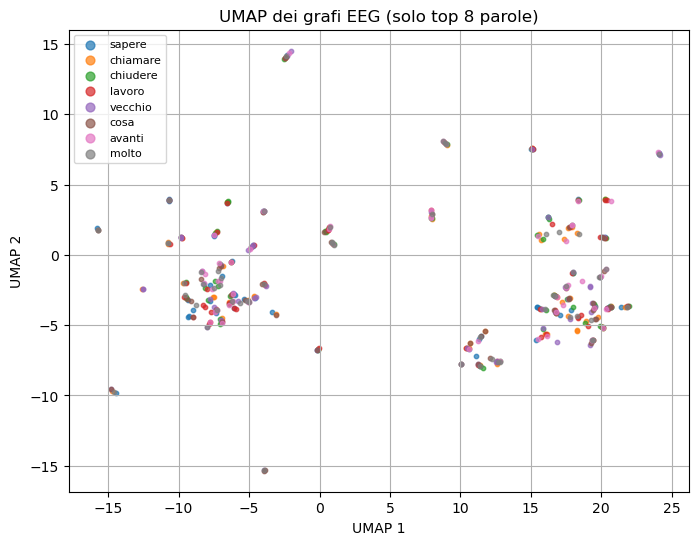

In [ ]:
# UMAP embedding of graph-level vectors
import umap
from sklearn.preprocessing import StandardScaler
from collections import Counter
num_graphs = len(X_epochs)
print("Num graphs totali:", num_graphs)
#max_samples = 5000
idx = np.random.choice(num_graphs, size=min(max_samples, num_graphs), replace=False)
X_flat = []
y_flat = []
for i in idx:
    x = X_epochs[i]
    x_vec = x.reshape(-1).numpy()
    X_flat.append(x_vec)
    y_flat.append(y_epochs[i])
X_flat = np.stack(X_flat, axis=0)
y_flat = np.array(y_flat)
scaler = StandardScaler()
X_flat_scaled = scaler.fit_transform(X_flat)
umap_model = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)
X_umap = umap_model.fit_transform(X_flat_scaled)
labels_text = np.array([idx2label[int(y)] for y in y_flat])
cnt = Counter(labels_text)
top_words = [w for w, _ in cnt.most_common(8)]
plt.figure(figsize=(8, 6))
for w in top_words:
    m = labels_text == w
    plt.scatter(X_umap[m, 0], X_umap[m, 1], s=10, alpha=0.7, label=w)
plt.legend(markerscale=2, fontsize=8)
plt.title("UMAP dei grafi EEG (solo top 8 parole)")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.grid(True)
plt.show()

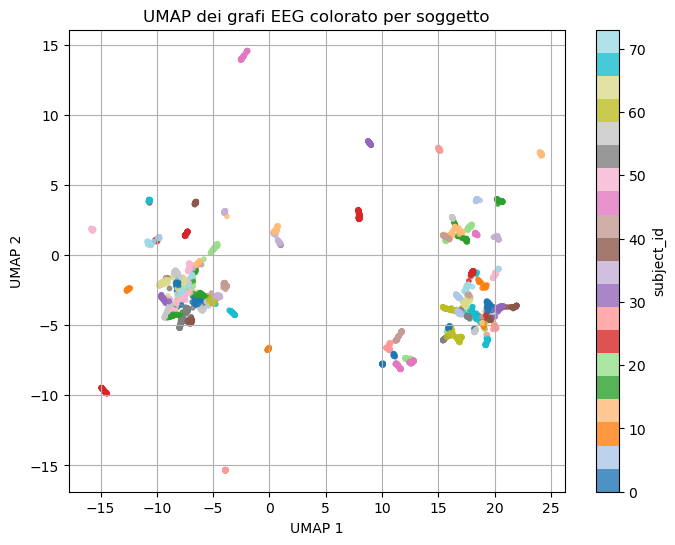

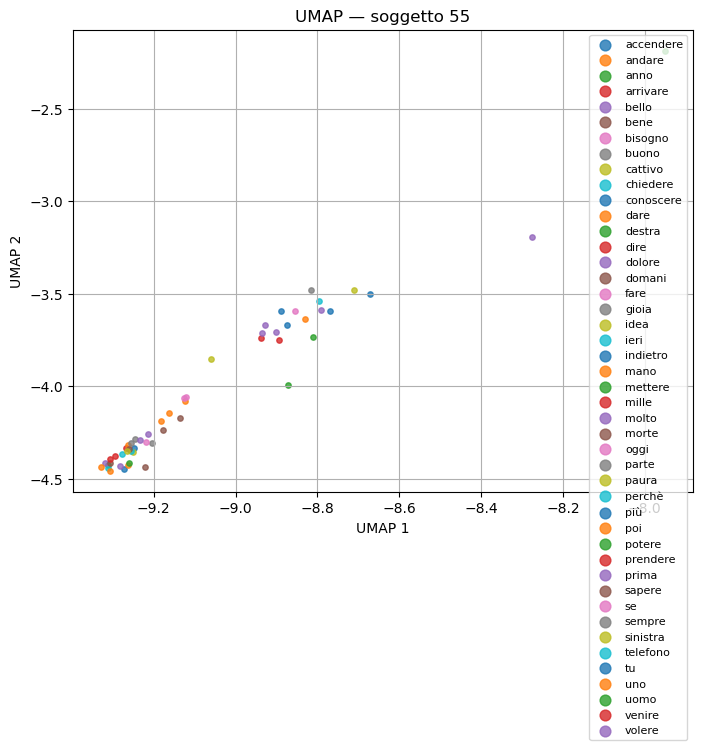

In [ ]:
# Color by subject and per-subject view
subjects = np.array([meta_epochs[i]["subject_id"] for i in idx])
plt.figure(figsize=(8, 6))
sc = plt.scatter(X_umap[:, 0], X_umap[:, 1], c=subjects, cmap="tab20", s=10, alpha=0.8)
plt.colorbar(sc, label="subject_id")
plt.title("UMAP dei grafi EEG colorato per soggetto")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.grid(True)
plt.show()

# Per-subject example (change subject_target as needed)
subject_target = subjects[0]
mask = subjects == subject_target
plt.figure(figsize=(8, 6))
for w in np.unique(labels_text[mask]):
    m = mask & (labels_text == w)
    plt.scatter(X_umap[m, 0], X_umap[m, 1], s=15, alpha=0.8, label=w)
plt.legend(markerscale=2, fontsize=8)
plt.title(f"UMAP — soggetto {subject_target}")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.grid(True)
plt.show()

## Structural Graph

Create a structural graph based on electrode positions (k-NN). Visualize the montage and the resulting graph.

<DigMontage | 0 extras (headshape), 0 HPIs, 0 fiducials, 63 channels>
['A1', 'AF7', 'AF3', 'Fp1', 'FP2', 'AF4', 'AF8', 'A2', 'F7', 'F5']
3 duplicate electrode labels found:
A1/A2, A1/Cz, A2/Cz
A1/A2, A1/Cz, A2/Cz
Plotting 60 unique labels.
Plotting 60 unique labels.


/var/folders/nf/98xxwv1511dfz5j4f3x3jqgc0000gn/T/ipykernel_25398/3092496467.py:7: RuntimeWarning: Fiducial point nasion not found, assuming identity unknown to head transformation
  mne.viz.plot_montage(montage, show_names=True)


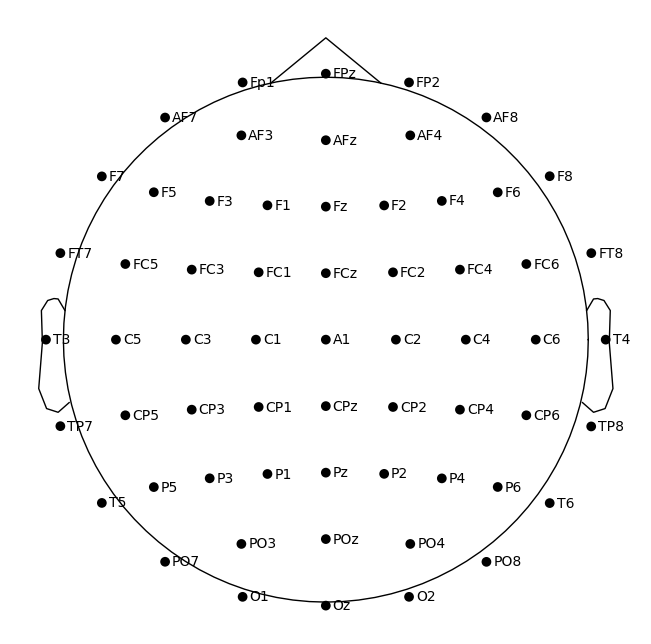

Name mapping: {'A1': 'A1', 'A2': 'A2', 'AF3': 'AF3', 'AF4': 'AF4', 'AF7': 'AF7', 'AF8': 'AF8', 'AFz': 'AFz', 'C1': 'C1', 'C2': 'C2', 'C3': 'C3', 'C4': 'C4', 'C5': 'C5', 'C6': 'C6', 'CP1': 'CP1', 'CP2': 'CP2', 'CP3': 'CP3', 'CP4': 'CP4', 'CP5': 'CP5', 'CP6': 'CP6', 'CPz': 'CPz', 'Cz': 'Cz', 'F1': 'F1', 'F2': 'F2', 'F3': 'F3', 'F4': 'F4', 'F5': 'F5', 'F6': 'F6', 'F7': 'F7', 'F8': 'F8', 'FC1': 'FC1', 'FC2': 'FC2', 'FC3': 'FC3', 'FC4': 'FC4', 'FC5': 'FC5', 'FC6': 'FC6', 'FCz': 'FCz', 'FP2': 'FP2', 'FPz': 'FPz', 'FT7': 'FT7', 'FT8': 'FT8', 'Fp1': 'Fp1', 'Fz': 'Fz', 'O1': 'O1', 'O2': 'O2', 'Oz': 'Oz', 'P1': 'P1', 'P2': 'P2', 'P3': 'P3', 'P4': 'P4', 'P5': 'P5', 'P6': 'P6', 'PO3': 'PO3', 'PO4': 'PO4', 'PO7': 'PO7', 'PO8': 'PO8', 'T3': 'T3', 'T4': 'T4', 'T5': 'T5', 'T6': 'T6', 'TP7': 'TP7', 'TP8': 'TP8'}
Missing: []
coords shape: (61, 3)


In [65]:
# Montage and channel coordinates
import mne
eloc_path = project_root / "src/io/ebneuro.locs"
montage = mne.channels.read_custom_montage(str(eloc_path))
print(montage)
print(montage.ch_names[:10])
mne.viz.plot_montage(montage, show_names=True)

channels_order = sorted(df_features["channel_std"].unique())
pos_dict = montage.get_positions()["ch_pos"]
name_map = {}
missing = []
for ch in channels_order:
    found = [m for m in pos_dict.keys() if m.lower() == ch.lower()]
    if found:
        name_map[ch] = found[0]
    else:
        missing.append(ch)
print("Name mapping:", name_map)
print("Missing:", missing)
channels_used = list(name_map.keys())
coords = np.stack([pos_dict[name_map[ch]] for ch in channels_used])
print("coords shape:", coords.shape)

In [66]:
# Build structural edge index (k-NN)
from sklearn.metrics import pairwise_distances
import torch
def build_structural_edge_index(coords, k=4):
    D = pairwise_distances(coords)
    n = len(coords)
    edges = set()
    for i in range(n):
        nn = np.argsort(D[i])[1:k+1]
        for j in nn:
            edges.add(tuple(sorted((i, j))))
    src, dst = [], []
    for a, b in edges:
        src += [a, b]
        dst += [b, a]
    return torch.tensor([src, dst], dtype=torch.long)
edge_index = build_structural_edge_index(coords, k=4)
print("edge_index:", edge_index.shape)

edge_index: torch.Size([2, 276])


In [67]:
# Create PyG Data objects (one per epoch)
# Install torch-geometric in the environment if needed (outside notebook prefer conda)
from torch_geometric.data import Data
graphs = []
for X, y, meta in zip(X_epochs, y_epochs, meta_epochs):
    g = Data(x=X, edge_index=edge_index, y=torch.tensor([y]))
    graphs.append(g)
print("Num graphs:", len(graphs))
print(graphs[0])

Num graphs: 38562
Data(x=[61, 40], edge_index=[2, 276], y=[1])


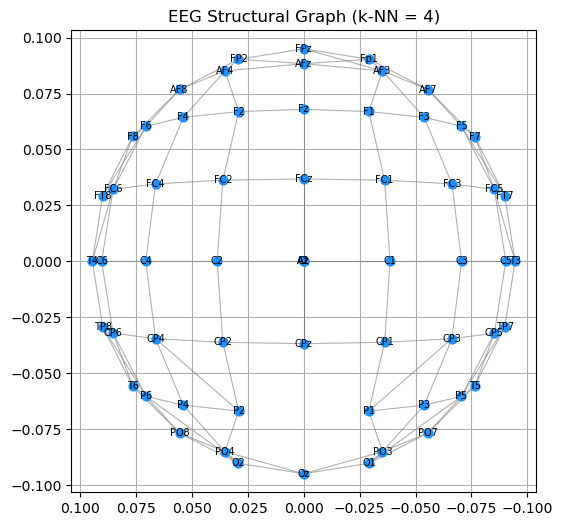

In [68]:
# Plot structural graph overlayed on 2D coords
x = coords[:, 0]
y = coords[:, 1]
plt.figure(figsize=(6, 6))
ei = edge_index.numpy()
for s, t in ei.T:
    plt.plot([x[s], x[t]], [y[s], y[t]], color="gray", alpha=0.4, linewidth=0.7)
plt.scatter(x, y, c="dodgerblue", s=40, zorder=3)
for i, ch in enumerate(channels_used):
    plt.text(x[i], y[i], ch, fontsize=7, ha="center", va="center")
plt.gca().invert_xaxis()
plt.axis("equal")
plt.title("EEG Structural Graph (k-NN = 4)")
plt.grid(True)
plt.show()

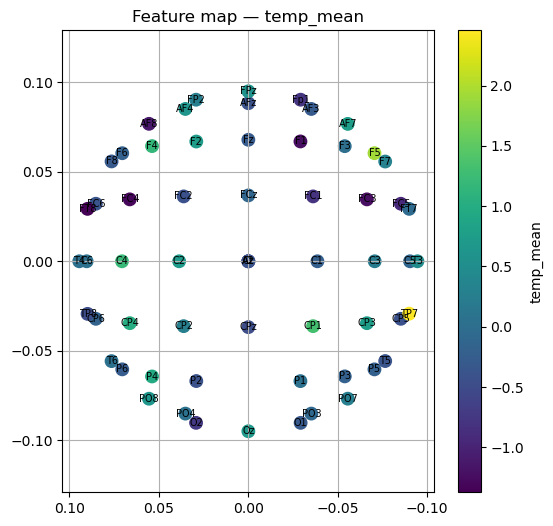

In [69]:
# Example: map a single feature across electrodes
epoch_id = 0
feat_idx = 0
feat_name = feature_cols[feat_idx]
feat = X_epochs[epoch_id][:, feat_idx].numpy()
plt.figure(figsize=(6, 6))
sc = plt.scatter(coords[:, 0], coords[:, 1], c=feat, cmap="viridis", s=80)
plt.colorbar(sc, label=feat_name)
for i, ch in enumerate(channels_used):
    plt.text(coords[i, 0], coords[i, 1], ch, fontsize=7, ha="center", va="center")
plt.title(f"Feature map — {feat_name}")
plt.gca().invert_xaxis()
plt.axis("equal")
plt.grid(True)
plt.show()